In [70]:
pip install imbalanced-learn

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [105]:
df = pd.read_csv("/content/insurance2.csv")

le = LabelEncoder()
scaler = StandardScaler()

for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col])
  else:
    df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))



for col in df:
  if df[col].isnull().sum() > 0 and df[col].dtype != "object":
    df.fillna(df[col].mean(), inplace=True)


y = df['charges']
x = df.drop(['charges', 'insuranceclaim'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (1070, 6)
x_test : (268, 6)
y_train : (1070,)
y_test : (268,)



In [106]:
y.dtype

dtype('float64')

In [107]:
y

,charges
0,0.298584
1,-0.953689
2,-0.728675
3,0.719843
4,-0.776802
...,...
1333,-0.220551
1334,-0.914002
1335,-0.961596
1336,-0.930362


In [73]:
print(df)

           age       sex       bmi  children    smoker    region   charges  \
0    -1.438764 -1.010519 -0.453320 -0.908614  1.970587  1.343905  0.298584   
1    -1.509965  0.989591  0.509621 -0.078767 -0.507463  0.438495 -0.953689   
2    -0.797954  0.989591  0.383307  1.580926 -0.507463  0.438495 -0.728675   
3    -0.441948  0.989591 -1.305531 -0.908614 -0.507463 -0.466915  0.719843   
4    -0.513149  0.989591 -0.292556 -0.908614 -0.507463 -0.466915 -0.776802   
...        ...       ...       ...       ...       ...       ...       ...   
1333  0.768473  0.989591  0.050297  1.580926 -0.507463 -0.466915 -0.220551   
1334 -1.509965 -1.010519  0.206139 -0.908614 -0.507463 -1.372326 -0.914002   
1335 -1.509965 -1.010519  1.014878 -0.908614 -0.507463  0.438495 -0.961596   
1336 -1.296362 -1.010519 -0.797813 -0.908614 -0.507463  1.343905 -0.930362   
1337  1.551686 -1.010519 -0.261388 -0.908614  1.970587 -0.466915  1.311053   

      insuranceclaim  
0           0.841910  
1           0.841

In [74]:
print(y_train)

560    -0.336755
1285   -0.391207
1142    1.143909
969    -0.386072
486    -0.065679
          ...   
1095   -0.719445
1130   -0.387272
1294   -0.110636
860     2.713075
1126   -0.252430
Name: charges, Length: 1070, dtype: float64


In [75]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    explained_variance_score  )

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='reg:squarederror',
    tree_method='auto')

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

# accuracy_scores = accuracy_score(y_test, y_pred)
# precision_scores = precision_score(y_test, y_pred)
# recall_scores = recall_score(y_test, y_pred)
# f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# print(f"""
# Accuracy Score : {accuracy_scores}
# Precision Score : {precision_scores}
# Recall Score : {recall_scores}
# F1 Score : {f1_scores} """)

r2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2_score}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.8540069989703252
Mean Absolute Error: 0.22985792024127338
Mean Squared Error: 0.1546663049897595


In [76]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
# disp.plot(cmap=plt.cm.Blues)
# plt.xlabel('Predicted student data')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [77]:
# print(classification_report(y_test, y_pred))

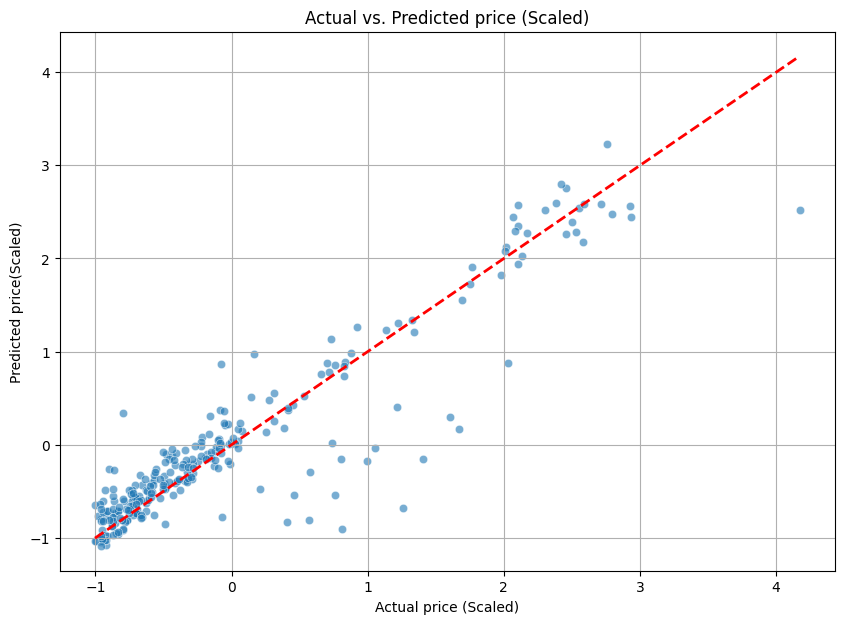

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted price (Scaled)')
plt.xlabel('Actual price (Scaled)')
plt.ylabel('Predicted price(Scaled)')
plt.grid(True)
plt.show()

In [112]:
df = pd.read_csv("/content/insurance2.csv")
print(df)

      age  sex     bmi  children  smoker  region      charges  insuranceclaim
0      19    0  27.900         0       1       3  16884.92400               1
1      18    1  33.770         1       0       2   1725.55230               1
2      28    1  33.000         3       0       2   4449.46200               0
3      33    1  22.705         0       0       1  21984.47061               0
4      32    1  28.880         0       0       1   3866.85520               1
...   ...  ...     ...       ...     ...     ...          ...             ...
1333   50    1  30.970         3       0       1  10600.54830               0
1334   18    0  31.920         0       0       0   2205.98080               1
1335   18    0  36.850         0       0       2   1629.83350               1
1336   21    0  25.800         0       0       3   2007.94500               0
1337   61    0  29.070         0       1       1  29141.36030               1

[1338 rows x 8 columns]


In [113]:
df["insuranceclaim"].dtype

dtype('int64')

In [115]:
df = pd.read_csv("/content/insurance2.csv")

le = LabelEncoder()
scaler = StandardScaler()


for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col])
  elif df[col].dtype != "object" and df[col].dtype != "int64":
    df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))
  else:
    df[col] = df[col]


for col in df:
  if df[col].isnull().sum() > 0 and df[col].dtype != "object":
    df.fillna(df[col].mean(), inplace=True)

y = df['insuranceclaim']
x = df.drop(['charges', 'insuranceclaim'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (1070, 6)
x_test : (268, 6)
y_train : (1070,)
y_test : (268,)



In [116]:
df['insuranceclaim'].dtype

dtype('int64')

In [117]:
print(y)

0       1
1       1
2       0
3       0
4       1
       ..
1333    0
1334    1
1335    1
1336    0
1337    1
Name: insuranceclaim, Length: 1338, dtype: int64


In [119]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='binary:logistic'
    # tree_method='auto'
   )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")


Accuracy Score : 0.9664179104477612
Precision Score : 0.9691358024691358
Recall Score : 0.9751552795031055
F1 Score : 0.9721362229102167 


              precision    recall  f1-score   support

           0       0.96      0.95      0.96       107
           1       0.97      0.98      0.97       161

    accuracy                           0.97       268
   macro avg       0.97      0.96      0.96       268
weighted avg       0.97      0.97      0.97       268



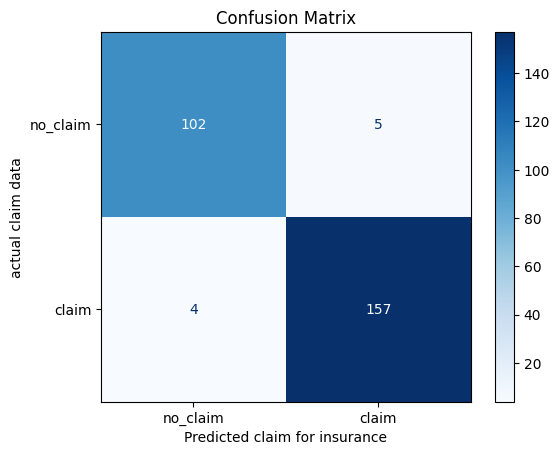

In [120]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no_claim', 'claim']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)

plt.xlabel('Predicted claim for insurance')
plt.ylabel('actual claim data')
plt.title('Confusion Matrix')
plt.show()

In [121]:
import joblib
if joblib.dump(xgb_model, 'insurance_classification.pkl'):
  print("model saved")

model saved
